In [48]:
import numpy as np
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge, LinearRegression
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

PROCESSED_DIR = Path("../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "barcelona_treino.csv"
test_path = PROCESSED_DIR / "barcelona_teste.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


In [49]:

target = "realSum"

X_train = df_train.drop(columns=[target])
y_train = df_train[target]


X_test = df_test.drop(columns=[target])
y_test = df_test[target]

print(df_train.shape)
print(df_test.shape)
print(X_test.shape)


(2266, 14)
(567, 14)
(567, 13)


In [50]:
def analise_hiperparametro(model, features, target, idx):

    param_space = [{"alpha": np.logspace(-4, 4, 100),     
                   "fit_intercept": [True, False],
                    "solver": ["auto", "svd"],
                    "positive": [False, True] },
                    {     
                   "fit_intercept": [True, False],
                    "positive": [False, True]} ]
    
    grid = GridSearchCV(model, param_space[idx], cv=KFold(n_splits=5, random_state=42, shuffle=True))
    grid.fit(features, target)
    print("Melhores hiperparâmetros:")
    print(grid.best_params_)

    return grid.best_estimator_

def linear_regression(features, target, test_features, idx):
    
    models = [Ridge, LinearRegression]
    model = models[idx]()
    best_model = analise_hiperparametro(model, features, target, idx)
    target_pred = best_model.predict(test_features)

    return target_pred, best_model

In [51]:
# Com features day
y_pred_ridge, best_model_ridge = linear_regression(X_train, y_train, X_test, 0) # com regularização

y_pred_ols, best_model_ols = linear_regression(X_train, y_train, X_test, 1) # sem regularização

# Sem features day
X_train_no_day = X_train.drop(columns=["day"])
X_test_no_day = X_test.drop(columns=["day"])

y_pred_no_day_ridge, best_model_ridge_no_day = linear_regression(X_train_no_day, y_train, X_test_no_day, 0)
y_pred_no_day_ols, best_model_ols_no_day = linear_regression(X_train_no_day, y_train, X_test_no_day, 1)


/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1000 fits failed out of a total of 4000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1000 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/mari/Documents

Melhores hiperparâmetros:
{'alpha': np.float64(0.9111627561154896), 'fit_intercept': True, 'positive': False, 'solver': 'svd'}
Melhores hiperparâmetros:
{'fit_intercept': True, 'positive': False}
Melhores hiperparâmetros:
{'alpha': np.float64(0.9111627561154896), 'fit_intercept': True, 'positive': False, 'solver': 'auto'}
Melhores hiperparâmetros:
{'fit_intercept': True, 'positive': False}


/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1000 fits failed out of a total of 4000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1000 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mari/Documents/Projeto-aprendizagem-de-maquina-/venv/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/mari/Documents

In [52]:
def scores(test, pred, s):
    
    mse = mean_squared_error(test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(test, pred)

    print("==================")
    print(f"Scores {s}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")



In [53]:
print("=======Com feature day =======")

scores(y_test, y_pred_ridge, "Ridge")
scores(y_test, y_pred_ols, "OLS")

print("=======Sem feature day =======")
scores(y_test, y_pred_no_day_ridge, "No Day Ridge")
scores(y_test, y_pred_no_day_ols, "No Day OLS")


=======Com feature day =======
Scores Ridge
MSE : 0.0063
RMSE: 0.0792
R²  : 0.5957
Scores OLS
MSE : 0.0063
RMSE: 0.0792
R²  : 0.5955
=======Sem feature day =======
Scores No Day Ridge
MSE : 0.0065
RMSE: 0.0809
R²  : 0.5775
Scores No Day OLS
MSE : 0.0065
RMSE: 0.0809
R²  : 0.5773


In [54]:
def plot_linreg(y_pred):
    y = df_test['realSum']

    plt.scatter(y, y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('Valores atuais')
    plt.ylabel('Valores previstos')
    plt.title('Regressão Linear OLS - Atual vs Previsão')
    plt.tight_layout()
    plt.show()    

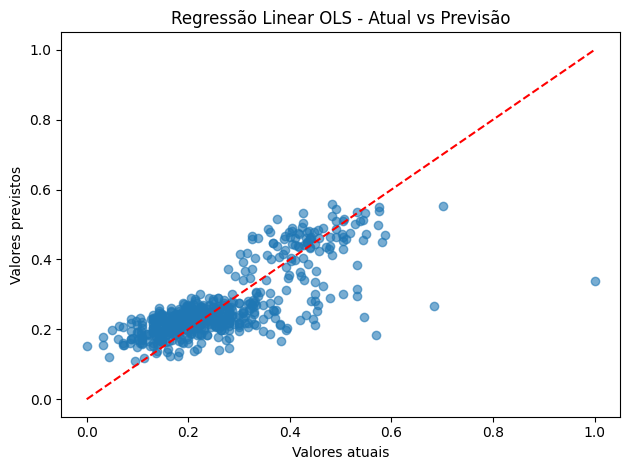

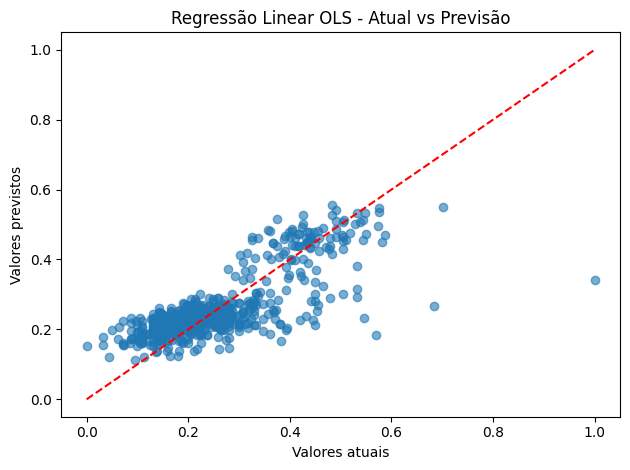

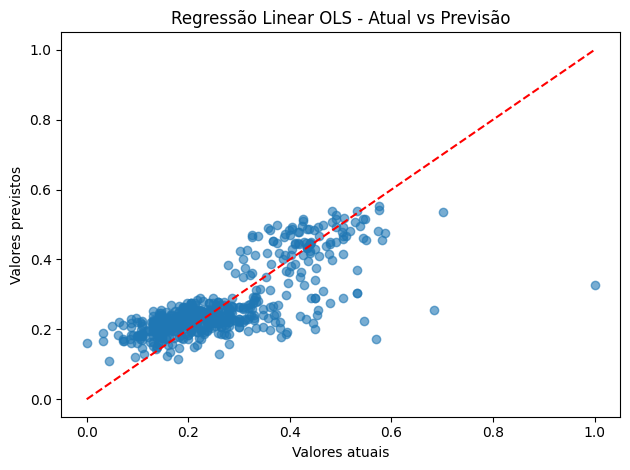

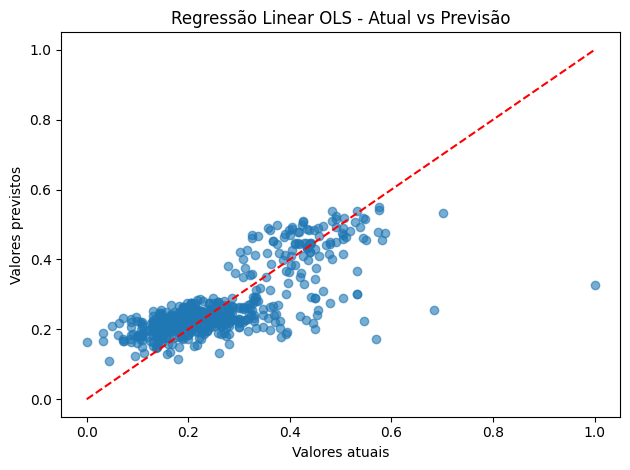

In [ ]:

plot_linreg(y_pred_ols)
plot_linreg(y_pred_ridge)
plot_linreg(y_pred_no_day_ols)
plot_linreg(y_pred_no_day_ridge)

In [ ]:
from sklearn.inspection import permutation_importance

result_ridge_noday = permutation_importance(
    best_model_ridge_no_day,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_ridge_noday = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_ridge_noday.importances_mean
}).sort_values("importance", ascending=False)



result_ols_noday = permutation_importance(
    best_model_ols_no_day,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_ols_noday = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_ols_noday.importances_mean
}).sort_values("importance", ascending=False)


In [57]:
from sklearn.inspection import permutation_importance

result_ridge = permutation_importance(
    best_model_ridge,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_ridge = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_ridge.importances_mean
}).sort_values("importance", ascending=False)



result_ols = permutation_importance(
    best_model_ols,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_ols = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result_ols.importances_mean
}).sort_values("importance", ascending=False)


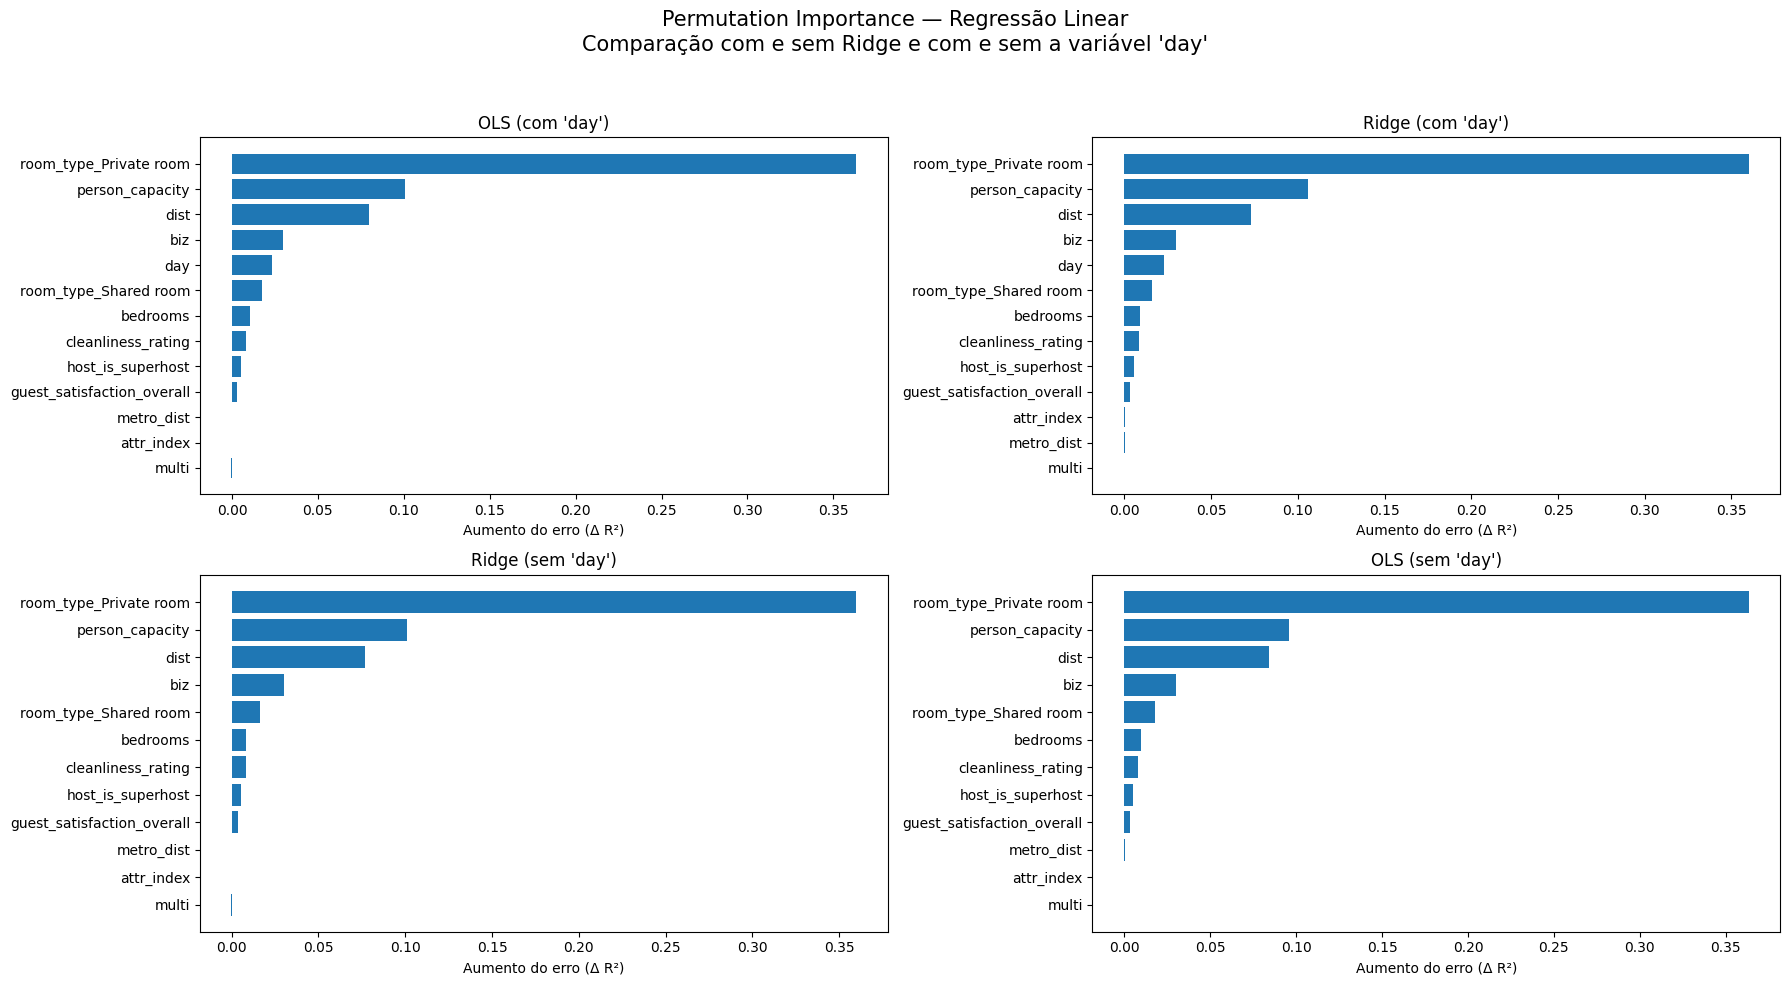

In [60]:
TOP_K = 15

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 10),
    
)

# Flatten axes for easy indexing
axes = axes.ravel()

# ---- 1. OLS (with day) ----
axes[0].barh(
    importance_ols["feature"][:TOP_K][::-1],
    importance_ols["importance"][:TOP_K][::-1]
)
axes[0].set_title("OLS (com 'day')")
axes[0].set_xlabel("Aumento do erro (Δ R²)")

# ---- 2. Ridge (with day) ----
axes[1].barh(
    importance_ridge["feature"][:TOP_K][::-1],
    importance_ridge["importance"][:TOP_K][::-1]
)
axes[1].set_title("Ridge (com 'day')")
axes[1].set_xlabel("Aumento do erro (Δ R²)")

# ---- 3. Ridge (without day) ----
axes[2].barh(
    importance_ridge_noday["feature"][:TOP_K][::-1],
    importance_ridge_noday["importance"][:TOP_K][::-1]
)
axes[2].set_title("Ridge (sem 'day')")
axes[2].set_xlabel("Aumento do erro (Δ R²)")

# ---- 4. OLS (without day) ----
axes[3].barh(
    importance_ols_noday["feature"][:TOP_K][::-1],
    importance_ols_noday["importance"][:TOP_K][::-1]
)
axes[3].set_title("OLS (sem 'day')")
axes[3].set_xlabel("Aumento do erro (Δ R²)")

# ---- Global title ----
plt.suptitle(
    "Permutation Importance — Regressão Linear\n"
    "Comparação com e sem Ridge e com e sem a variável 'day'",
    fontsize=15
)

# Layout fix so the suptitle is not clipped
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()